# 实验十：综合应用实验 —— 文档扫描矫正系统

**实验目的：**
综合运用图像预处理、边缘检测、轮廓提取、透视变换和自适应阈值技术，解决一个真实的商业场景问题。

**应用场景：**
这正是著名 APP“扫描全能王”或 iPhone 备忘录扫描功能背后的核心技术。


✅ 成功生成了一张拍歪的桌面文档！


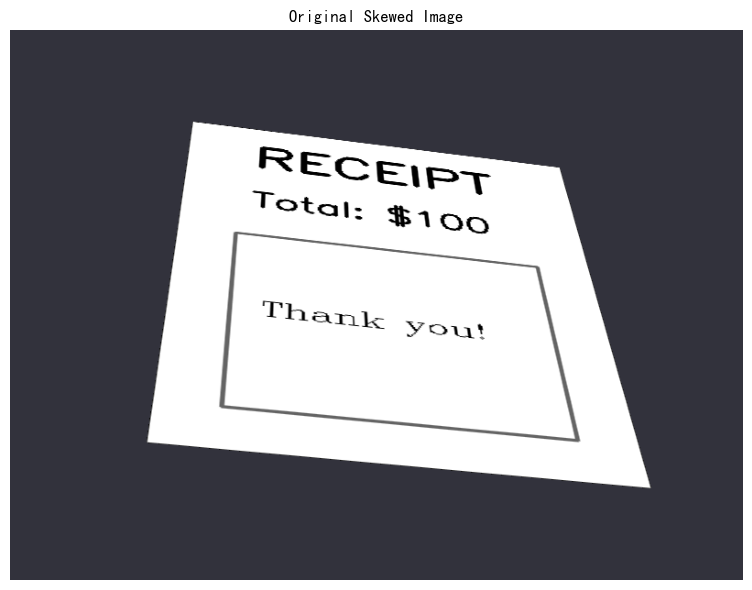

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 6)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i]
        if len(img.shape) == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# 0. 自动生成一张“被拍歪的文档”测试图
# ==========================================
# 创建一个深色背景 (模拟桌面)
bg = np.full((600, 800, 3), (60, 50, 50), dtype=np.uint8)

# 创建一张平整的白色发票/文档
doc = np.full((400, 300, 3), 255, dtype=np.uint8)
cv2.putText(doc, "RECEIPT", (50, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,0,0), 3)
cv2.putText(doc, "Total: $100", (50, 120), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)
cv2.rectangle(doc, (40, 160), (260, 360), (100, 100, 100), 2)
cv2.putText(doc, "Thank you!", (60, 260), cv2.FONT_HERSHEY_COMPLEX, 0.8, (0,0,0), 1)

# 定义平整文档的四个角
pts_flat = np.float32([[0,0], [300,0], [300,400], [0,400]])
# 定义在画面中倾斜、透视变形后的四个角
pts_skewed = np.float32([[200, 100], [600, 150], [700, 500], [150, 450]]) 

# 计算透视变换矩阵，并把文档“拍歪”
M_skew = cv2.getPerspectiveTransform(pts_flat, pts_skewed)
warped_doc = cv2.warpPerspective(doc, M_skew, (800, 600))

# 将歪掉的文档贴到背景桌面上
mask = cv2.warpPerspective(np.ones_like(doc)*255, M_skew, (800, 600))
bg[mask > 0] = warped_doc[mask > 0]

orig_img = bg.copy()

print("✅ 成功生成了一张拍歪的桌面文档！")
show_images([orig_img], ["Original Skewed Image"])


## 第一步：预处理与边缘检测
这是我们在【实验三】和【实验七】学过的内容。为了抗干扰，先用高斯模糊去噪，然后用 Canny 算子提取边缘。


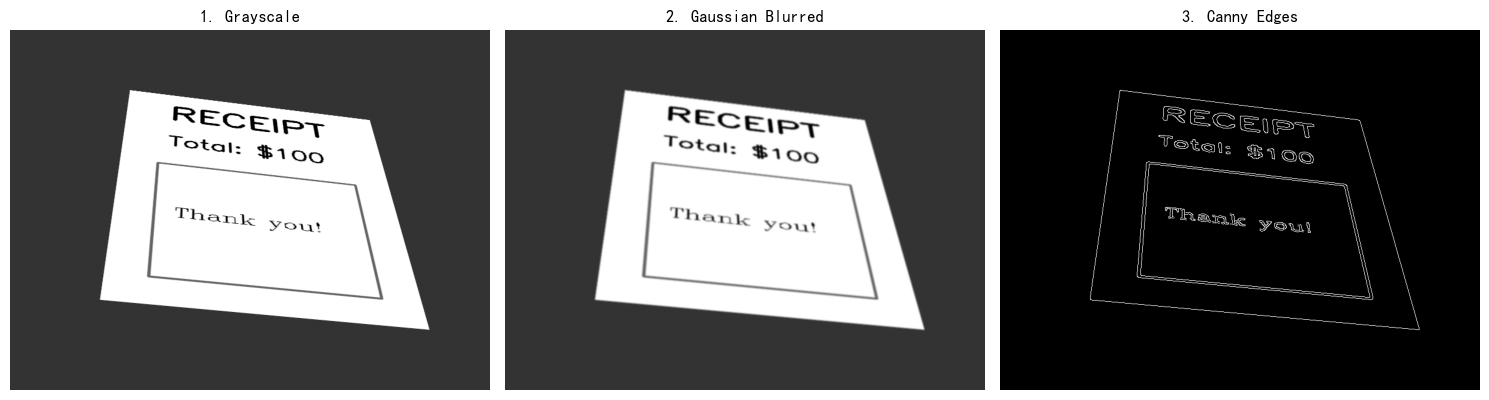

In [2]:
# 1. 转为灰度图
gray = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)

# 2. 高斯滤波 (平滑噪点，防止产生碎小的错误边缘)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Canny 边缘检测
edged = cv2.Canny(blurred, 75, 200)

show_images([gray, blurred, edged], 
            ["1. Grayscale", "2. Gaussian Blurred", "3. Canny Edges"])


## 第二步：寻找文档轮廓并提取四个顶点
利用形态学和轮廓查找技术，在纷繁复杂的边缘中，找出那张纸。
纸张通常是画面中**最大的、且拥有四个顶点的多边形**。


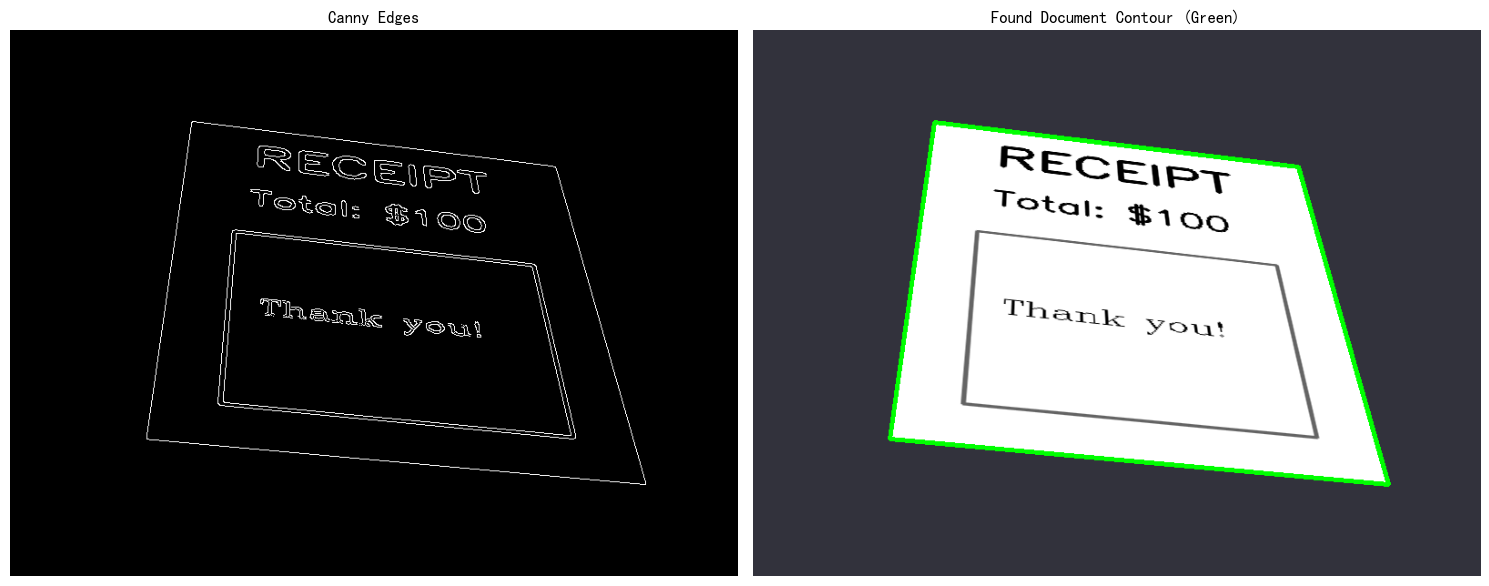

In [3]:
# 1. 寻找所有的轮廓
# RETR_LIST 检索所有轮廓，CHAIN_APPROX_SIMPLE 压缩水平/垂直线段只留端点
contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

# 2. 按照轮廓面积从大到小排序，我们只关注前 5 个最大的
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

doc_contour = None

# 3. 遍历这些大轮廓，寻找四边形
for c in contours:
    # 计算轮廓周长
    peri = cv2.arcLength(c, True)
    # 用多边形逼近算法 (Douglas-Peucker 算法) 来拟合轮廓
    # 0.02 * peri 是精度阈值，如果拟合出的多边形恰好有 4 个顶点，我们就认为找到了文档！
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    if len(approx) == 4:
        doc_contour = approx
        break

# 4. 在原图上画出找到的文档轮廓（绿色）
img_with_contour = orig_img.copy()
if doc_contour is not None:
    cv2.drawContours(img_with_contour, [doc_contour], -1, (0, 255, 0), 3)

show_images([edged, img_with_contour], 
            ["Canny Edges", "Found Document Contour (Green)"])


## 第三步：透视变换 (Perspective Transform) - 【核心魔法】
我们找到了倾斜文档的四个角，现在需要定义一个“平整的方块”，利用几何矩阵把倾斜的纸“拽”平！
这就需要用到我们在【实验九】中接触过的几何变换思想。


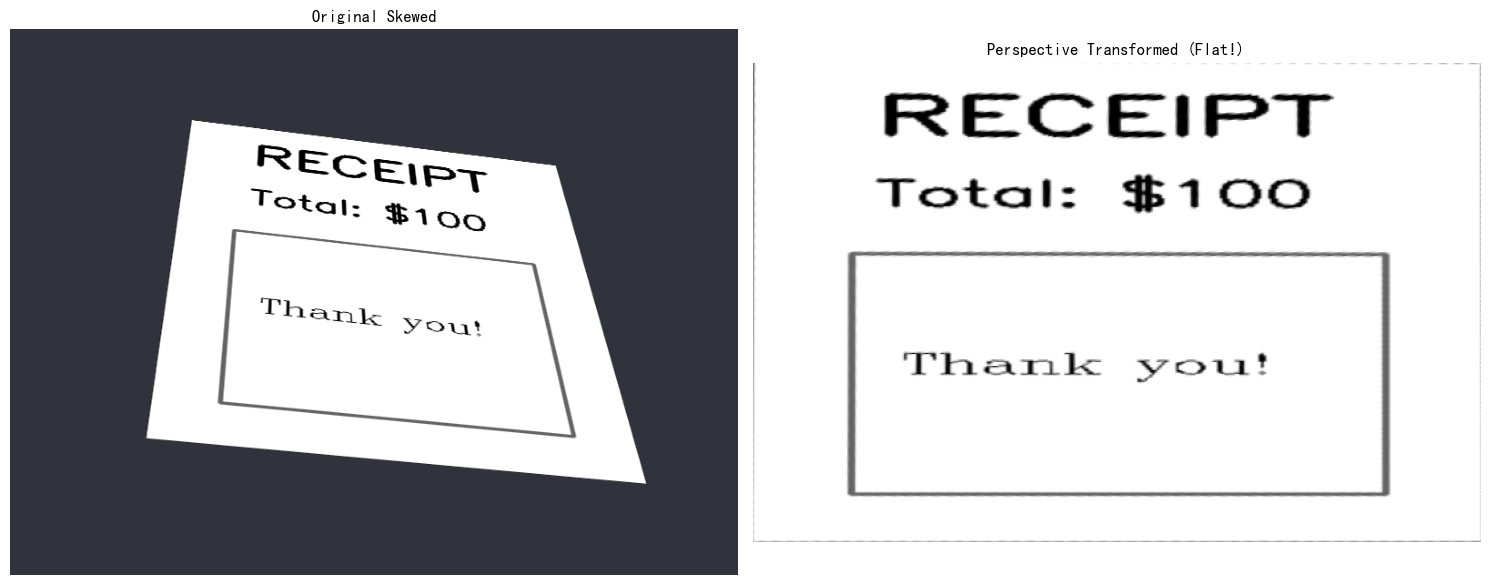

In [4]:
# 辅助函数：对找到的四个顶点按固定顺序排序 (左上, 右上, 右下, 左下)
# 这步非常重要，否则拉平的时候图像可能会发生翻转或扭曲
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    # 按坐标相加的和排序，最小的是左上，最大的是右下
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    # 按坐标相减的差排序，最小的是右上，最大的是左下
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

if doc_contour is not None:
    # 重塑并排序顶点
    pts = doc_contour.reshape(4, 2)
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # 计算新图像的宽度 (取顶部和底部宽度的最大值)
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # 计算新图像的高度 (取左侧和右侧高度的最大值)
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    # 构建目标点：一个标准的正矩形 (左上，右上，右下，左下)
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # 计算透视变换矩阵 (3x3 矩阵)
    M = cv2.getPerspectiveTransform(rect, dst)

    # 应用透视变换，把歪的画面“拉平”
    warped = cv2.warpPerspective(orig_img, M, (maxWidth, maxHeight))

    show_images([orig_img, warped], 
                ["Original Skewed", "Perspective Transformed (Flat!)"])


## 第四步：自适应阈值增强 (变身扫描件)
文档已经被拉平了，但可能有手机产生的阴影造成光照不均匀。
我们要用【实验七】学过的**阈值分割技术**。但全局阈值会因为阴影导致画面黑一块白一块，因此我们必须使用**自适应阈值 (Adaptive Thresholding)**！


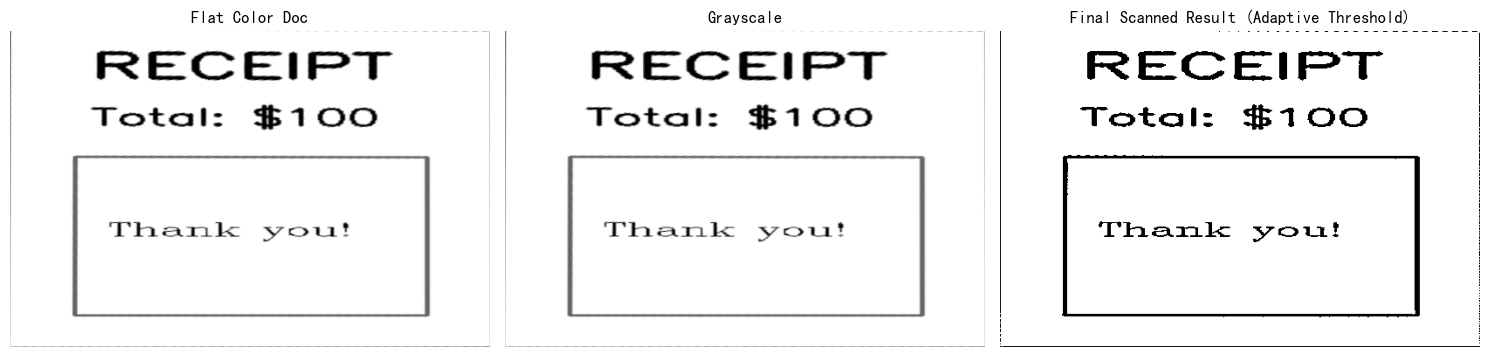

🎉 恭喜！你已经亲手撸出了一个完整的工业级文档扫描核心算法！


In [ ]:
if doc_contour is not None:
    # 1. 转换为灰度图
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

    # 2. 自适应阈值化
    # 算法会考察每个像素周围的小区块(这里是21x21)，根据局部光照来决定它是黑还是白
    scanned_effect = cv2.adaptiveThreshold(warped_gray, 255, 
                                           cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                           cv2.THRESH_BINARY, 21, 10)

    show_images([warped, warped_gray, scanned_effect], 
                ["Flat Color Doc", "Grayscale", "Final Scanned Result (Adaptive Threshold)"])

    print(" 恭喜！你已经亲手撸出了一个完整的工业级文档扫描核心算法！")
